In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt


In [53]:
def create_adjacency(ph):
    M = np.zeros((200,len(ph['barcode'][0])))
    for i in range(len(ph['representatives'])):
        for j in ph['representatives'][i]:
            M[j-1,i] = 1
    return M    

In [54]:
import os

def compute_forman_ricci_curvature(incidence_matrix, protein_id):
    """Compute both weighted and unweighted Forman-Ricci curvature for all hyperedges."""
    
    num_vertices, num_hyperedges = incidence_matrix.shape
    unweighted_curvature = {}
    
    for e in range(num_hyperedges):
        e_str = str(e + 1)  # Changed from str(e) to str(e+1) to make indices start at 1
        
        vertices_in_e = np.where(incidence_matrix[:, e] == 1)[0]
        sum_terms = 0.0

        
        # Compute unweighted curvature (2|e| - D)
        edge_size = len(vertices_in_e)
        node_degrees = [np.sum(incidence_matrix[k, :]) for k in vertices_in_e]
        D = sum(node_degrees)
        unweighted_curvature[e_str] = 2 * edge_size - D
    
    # Save weighted results
    try:
        # Save weighted JSON
        #weighted_curvature_path_json = os.path.join(edge_curvature_weighted_json_dir, f"{protein_id}.json")
        #with open(weighted_curvature_path_json, 'w') as f:
            #json.dump(weighted_curvature, f, indent=4)

        # Save weighted CSV
        #weighted_curvature_path_csv = os.path.join(edge_curvature_weighted_csv_dir, f"{protein_id}.csv")
        #pd.DataFrame(list(weighted_curvature.items()), columns=["HyperedgeIndex", "FormanRicciCurvature"]).to_csv(
            #weighted_curvature_path_csv, index=False)
            
        # Save unweighted JSON
        unweighted_curvature_path_json = os.path.join("curvatures", f"{protein_id}.json")
        with open(unweighted_curvature_path_json, 'w') as f:
            json.dump(unweighted_curvature, f, indent=4)

        # Save unweighted CSV
        #unweighted_curvature_path_csv = os.path.join(edge_curvature_unweighted_csv_dir, f"{protein_id}.csv")
        #pd.DataFrame(list(unweighted_curvature.items()), columns=["HyperedgeIndex", "FormanRicciCurvature"]).to_csv(
            #unweighted_curvature_path_csv, index=False)
    except Exception as e:
        print(f"Error saving results for {protein_id}: {str(e)}")
    
    return unweighted_curvature

In [55]:
def load_PH(type, L, j):
    with open("{}_jodelle_{}_{}_ph.json".format(type,L,j), 'r') as f:
        dic = json.load(f)
    return dic    

In [63]:
matrices_knots = [create_adjacency(a) for a in np.concatenate([load_PH('knots', 150,i) for i in range(10)])]
matrices_unknots = [create_adjacency(a) for a in np.concatenate([load_PH('unknots', 150,i) for i in range(10)])]

In [64]:
curvatures_knots = []
for i in range(len(matrices_knots)):
    M = matrices_knots[i]
    curvatures_knots.append(compute_forman_ricci_curvature(M, 'knot_{}'.format(i)))
curvatures_unknots = []
for i in range(len(matrices_unknots)):
    M = matrices_unknots[i]
    curvatures_unknots.append(compute_forman_ricci_curvature(M, 'knot_{}'.format(i)))

In [65]:
TOT = 500

df = pd.DataFrame()
df['Curvature'] = np.concatenate([[np.average(list(curvatures_knots[i].values())) for i in range(TOT)],[np.average(list(curvatures_unknots[i].values())) for i in range(TOT)]])
df['Type'] = np.concatenate([['knotted' for i in range(TOT)],['unknotted' for i in range(TOT)]])

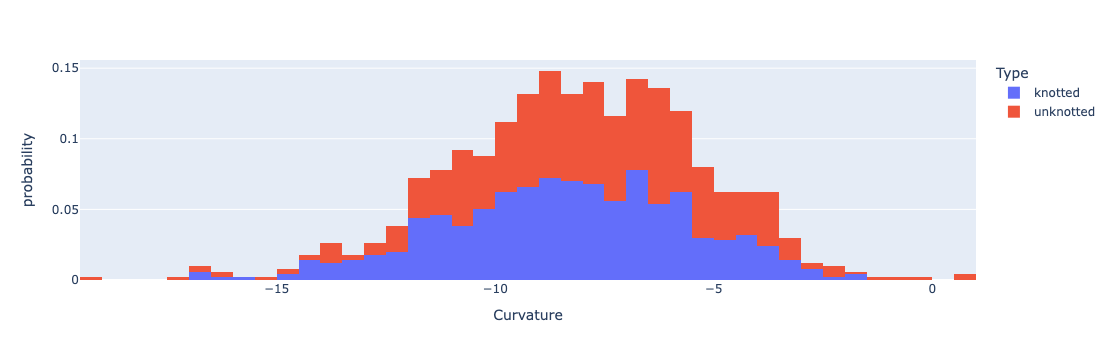

In [66]:
import plotly.express as px
px.histogram(df, x='Curvature', color = 'Type', histnorm='probability')

In [67]:
df

,Curvature,Type
0,-8.705882,knotted
1,-7.734694,knotted
2,-4.937500,knotted
3,-5.347826,knotted
4,-7.758621,knotted
...,...,...
995,-7.333333,unknotted
996,-7.521739,unknotted
997,-11.129630,unknotted
998,-4.384615,unknotted


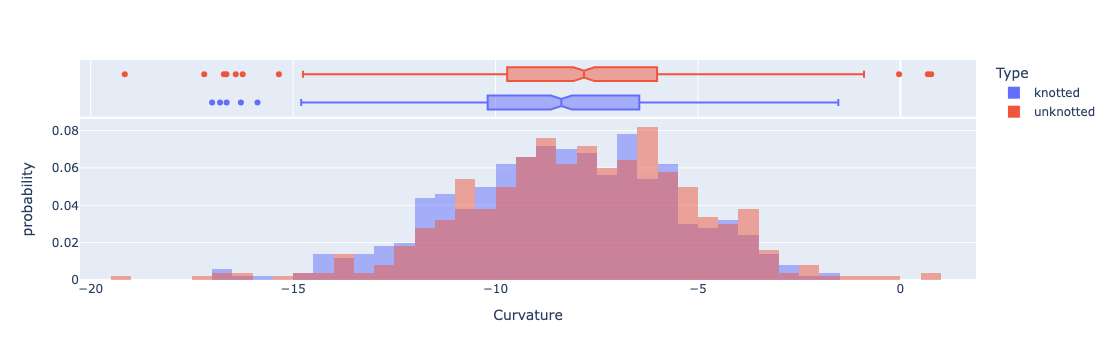

In [68]:
fig = px.histogram(df, x="Curvature", color="Type",
                   marginal="box", # or violin, rug
                   barmode='overlay',
                   histnorm='probability',
                   hover_data=df.columns)
fig.show()

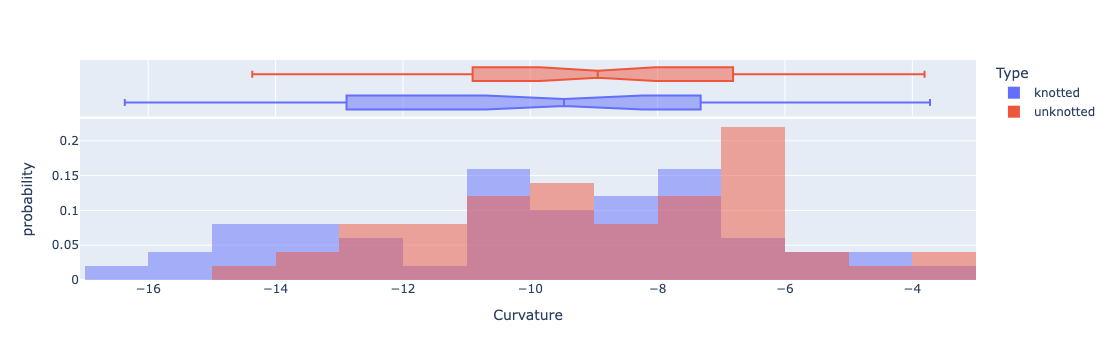

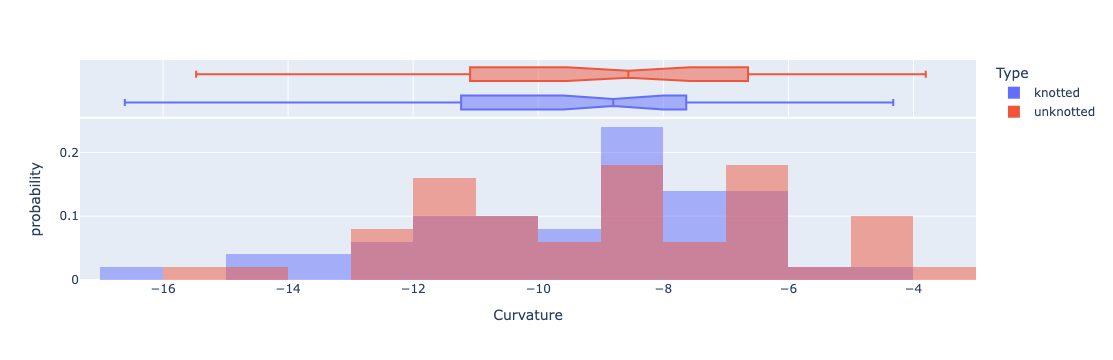

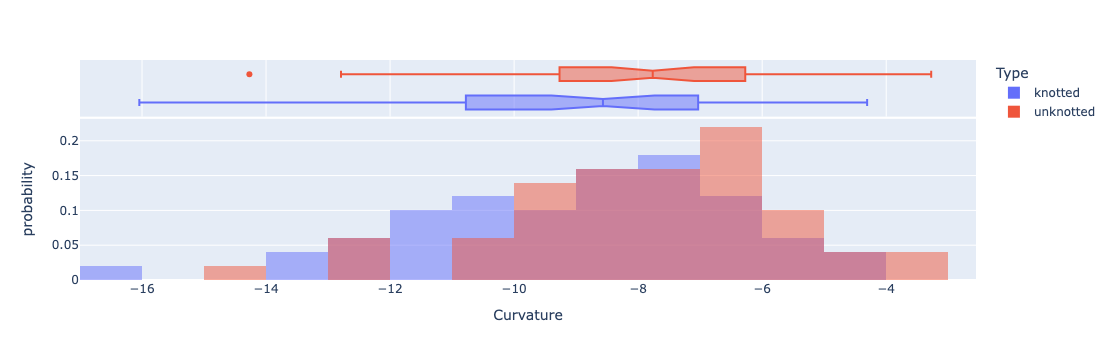

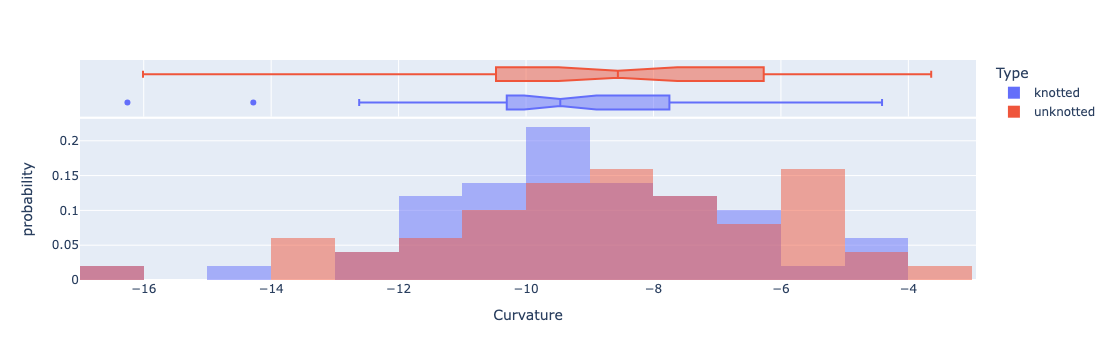

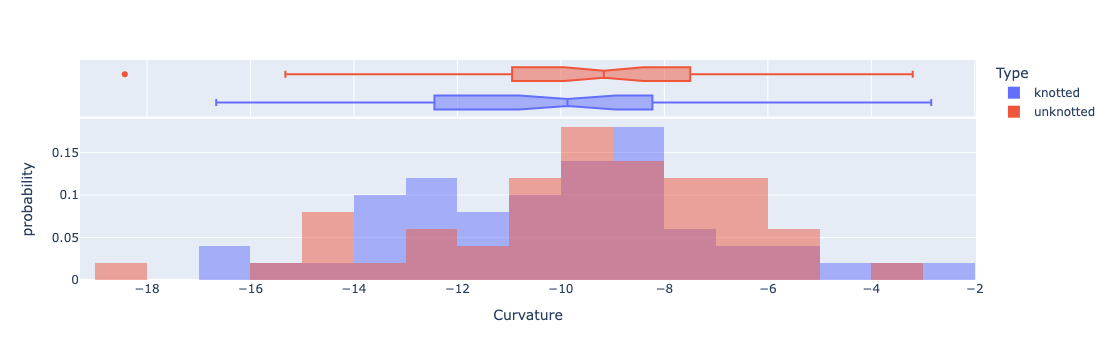

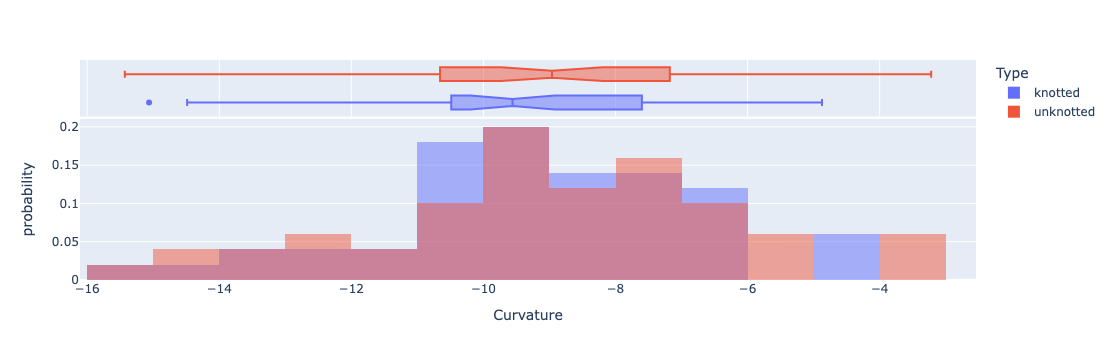

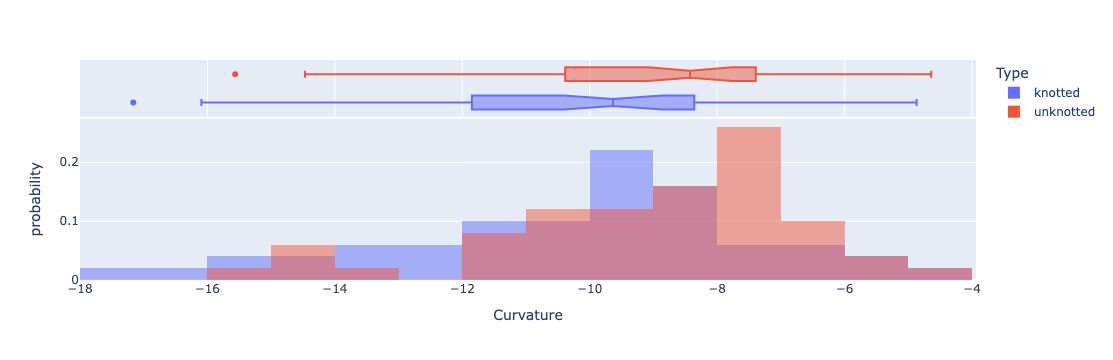

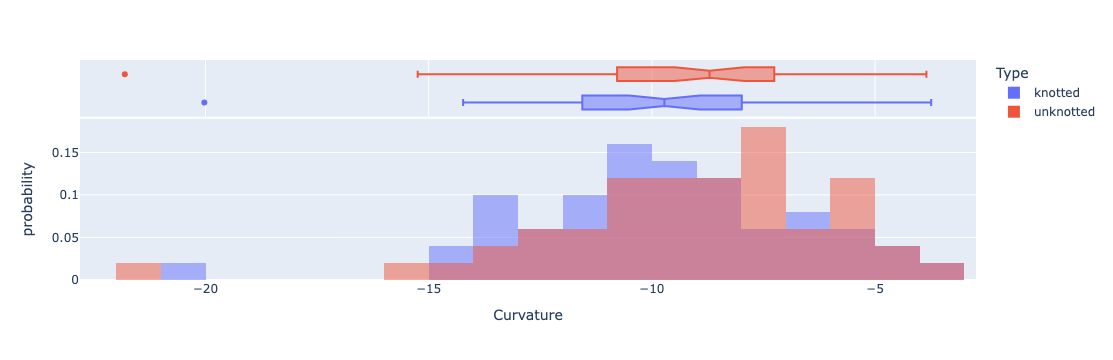

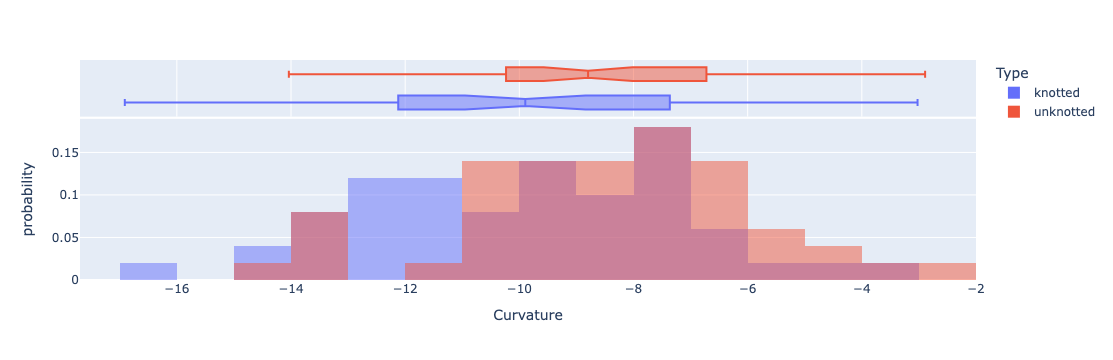

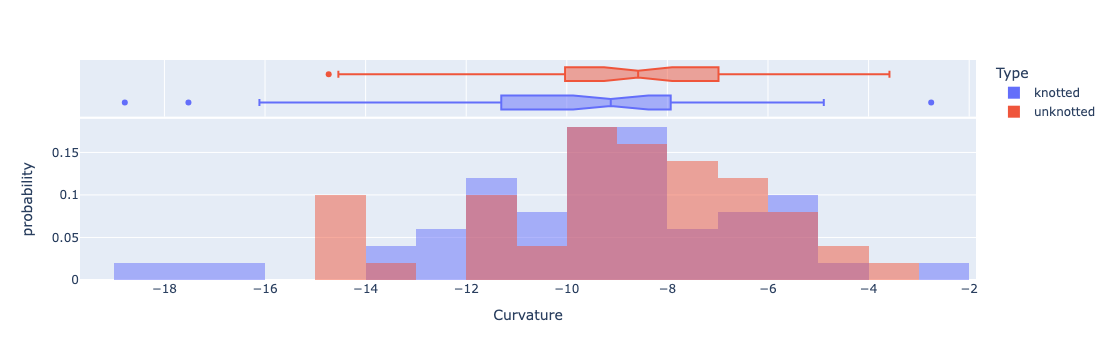

In [62]:
for i in range(10):
    df = pd.DataFrame()
    df['Curvature'] = np.concatenate([[np.average(list(curvatures_knots[i].values())) for i in range(50*i, 50*(i+1))],[np.average(list(curvatures_unknots[i].values())) for i in range(50*i, 50*(i+1))]])
    df['Type'] = np.concatenate([['knotted' for i in range(50*i, 50*(i+1))],['unknotted' for i in range(50*i, 50*(i+1))]])
    fig = px.histogram(df, x="Curvature", color="Type",
                   marginal="box", # or violin, rug
                   barmode='overlay',
                   histnorm='probability',
                   hover_data=df.columns)
    fig.show()

In [93]:
df

,Curvature,Type
0,-8.131579,knotted
1,-8.309524,knotted
2,-8.789474,knotted
3,-8.241379,knotted
4,-8.771429,knotted
...,...,...
95,-7.777778,unknotted
96,-6.000000,unknotted
97,-6.583333,unknotted
98,-6.966667,unknotted
